In [103]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize

from utils import convert_data, winsorize_cols, run_regression, difference_test_table
from col import cols, win_cols, dep_var, main_vars, control_vars, fe_vars

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### read data

In [104]:
# 轉換資料
df = pd.read_excel('主表.xlsx')
df = convert_data(df)

### describtion

In [105]:
# describe statistic
# ===== Winsorize 前的敘述性統計 =====
print("=== Winsorize 前 ===")
display(df[cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(3))

# ===== Winsorize 後的敘述性統計 =====
df_win = winsorize_cols(df, win_cols, limits=(0.01, 0.01))
print("=== Winsorize 後 ===")
display(df_win[cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(3))

=== Winsorize 前 ===


,count,mean,std,min,1%,25%,50%,75%,99%,max
Fund_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_month_lag1,8730.0,168.471,0.105,168.167,168.167,168.417,168.500,168.583,168.583,168.583
Firm_id,8826.0,4012.390,2182.708,1101.000,1134.250,2377.000,3044.000,5871.000,9938.000,9958.000
TSE,8826.0,22.311,7.921,1.000,1.250,20.000,24.000,27.000,37.000,38.000
Year,8826.0,2022.637,1.263,2019.000,2019.000,2022.000,2023.000,2024.000,2024.000,2024.000
...,...,...,...,...,...,...,...,...,...,...
Tangibility_r,8822.0,0.222,0.167,0.000,0.005,0.077,0.201,0.342,0.615,0.891
Board_Independ_r,8820.0,0.382,0.097,0.000,0.200,0.333,0.364,0.429,0.625,0.667
Age,8822.0,33.135,14.998,1.000,5.000,23.000,31.000,42.000,72.000,78.000
l_Age,8822.0,3.384,0.521,0.000,1.609,3.135,3.434,3.738,4.277,4.357


=== Winsorize 後 ===


,count,mean,std,min,1%,25%,50%,75%,99%,max
Fund_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_month_lag1,8730.0,168.471,0.105,168.167,168.167,168.417,168.500,168.583,168.583,168.583
Firm_id,8826.0,4012.390,2182.708,1101.000,1134.250,2377.000,3044.000,5871.000,9938.000,9958.000
TSE,8826.0,22.311,7.921,1.000,1.250,20.000,24.000,27.000,37.000,38.000
Year,8826.0,2022.637,1.263,2019.000,2019.000,2022.000,2023.000,2024.000,2024.000,2024.000
...,...,...,...,...,...,...,...,...,...,...
Tangibility_r,8822.0,0.222,0.165,0.005,0.005,0.077,0.201,0.342,0.615,0.615
Board_Independ_r,8820.0,0.382,0.097,0.200,0.200,0.333,0.364,0.429,0.625,0.625
Age,8822.0,33.135,14.998,1.000,5.000,23.000,31.000,42.000,72.000,78.000
l_Age,8822.0,3.390,0.496,1.609,1.609,3.135,3.434,3.738,4.277,4.277


### draw trend

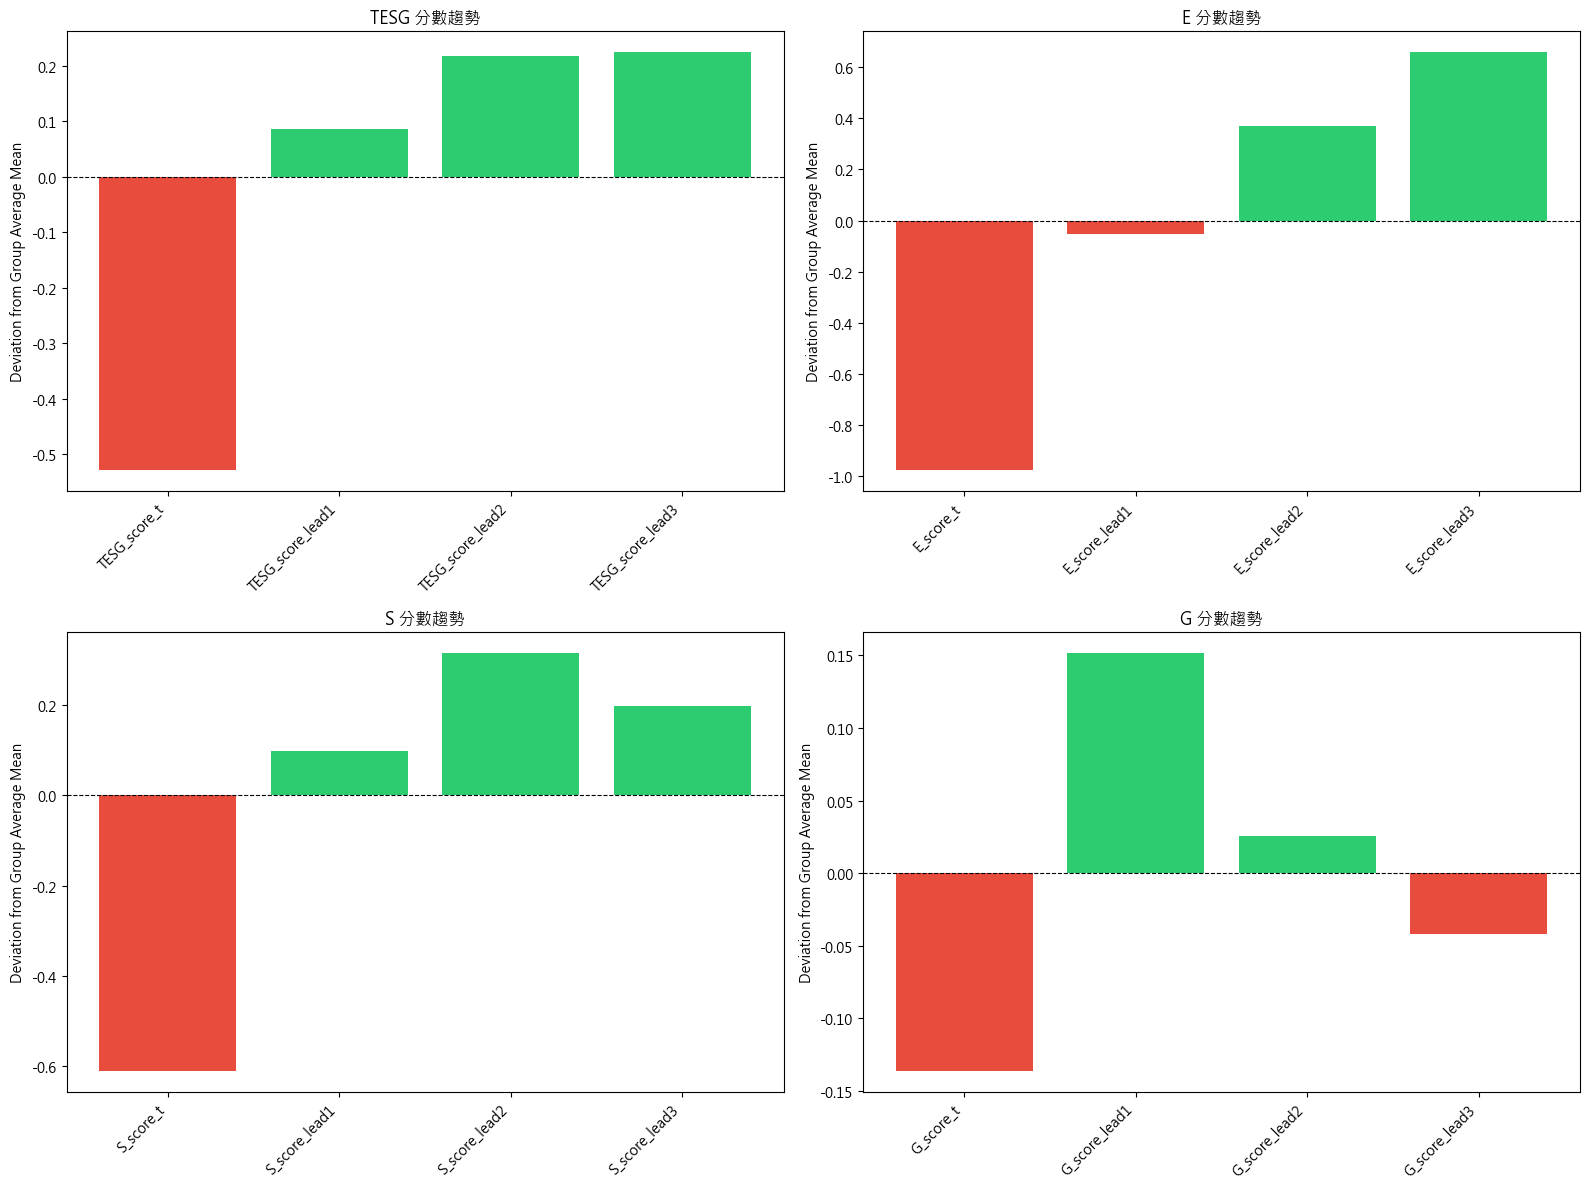

In [106]:
import matplotlib.pyplot as plt
from utils import plot_desc_bar

group1 = ['TESG_score_t', 'TESG_score_lead1', 'TESG_score_lead2', 'TESG_score_lead3']
group2 = ['E_score_t', 'E_score_lead1', 'E_score_lead2', 'E_score_lead3']
group3 = ['S_score_t', 'S_score_lead1', 'S_score_lead2', 'S_score_lead3']
group4 = ['G_score_t', 'G_score_lead1', 'G_score_lead2', 'G_score_lead3']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 左上 axes[0, 0], 右上 axes[0, 1], 左下 axes[1, 0], 右下 axes[1, 1]
plot_desc_bar(df_win, group1, demean=True, title='TESG 分數趨勢', ax=axes[0, 0])
plot_desc_bar(df_win, group2, demean=True, title='E 分數趨勢', ax=axes[0, 1])
plot_desc_bar(df_win, group3, demean=True, title='S 分數趨勢', ax=axes[1, 0])
plot_desc_bar(df_win, group4, demean=True, title='G 分數趨勢', ax=axes[1, 1])

# 自動調整子圖之間的間距，避免文字重疊
fig.tight_layout()

plt.show()
fig.savefig('四宮格趨勢圖.png', dpi=150, bbox_inches='tight')

### 樣本年份分配

In [107]:
vars = [
    'Conglo', 'Seg', 'Comp', 'Foreign_Dummy', 'Foreign_Sales_Ratio', 
    'TESG_score_t', 'E_score_t', 'S_score_t', 'G_score_t'
]

yearly_table = df_win.groupby('Year')[vars].mean()
yearly_table.insert(0, '樣本數', df_win.groupby('Year').size())

total_row = df_win[vars].mean()
total_row['樣本數'] = len(df_win)
yearly_table.loc['總計'] = total_row
yearly_table['樣本比例'] = (yearly_table['樣本數'] / yearly_table.loc['總計', '樣本數'] * 100).apply(lambda x: f'{x:.1f}%')
yearly_table['樣本數'] = yearly_table['樣本數'].astype(int)
yearly_table = yearly_table.round(3)

display(yearly_table)

,樣本數,Conglo,Seg,Comp,Foreign_Dummy,Foreign_Sales_Ratio,TESG_score_t,E_score_t,S_score_t,G_score_t,樣本比例
Year,,,,,,,,,,,
2019,168,0.888,3.283,0.329,0.000,0.688,61.435,62.855,63.744,59.199,1.9%
2020,377,0.869,3.068,0.301,0.148,0.714,62.880,64.114,65.141,60.410,4.3%
2021,1123,0.883,3.168,0.311,0.126,0.642,62.993,64.697,65.492,60.036,12.7%
2022,1910,0.902,3.122,0.310,0.141,0.637,63.219,65.642,65.124,60.596,21.6%
2023,2489,0.900,3.154,0.326,0.141,0.634,66.146,71.431,68.172,61.414,28.2%
2024,2759,0.906,3.080,0.309,0.135,0.671,65.798,72.158,66.919,61.033,31.3%
總計,8826,0.899,3.124,0.314,0.135,0.652,64.786,69.101,66.576,60.862,100.0%


### 產業分配

In [108]:
vars = [
    'Conglo', 'Seg', 'Comp', 'Foreign_Dummy', 'Foreign_Sales_Ratio', 
    'TESG_score_t', 'E_score_t', 'S_score_t', 'G_score_t'
]

industry_table = df_win.groupby('TSE')[vars].mean()
industry_table.insert(0, '樣本數', df_win.groupby('TSE').size())
industry_table.insert(1, 'Industry', df_win.groupby('TSE')['Industry'].first())

total_row = df_win[vars].mean()
total_row['樣本數'] = len(df_win)
industry_table.loc['總計'] = total_row
industry_table['樣本比例'] = (industry_table['樣本數'] / industry_table.loc['總計', '樣本數'] * 100).apply(lambda x: f'{x:.1f}%')
industry_table['樣本數'] = industry_table['樣本數'].astype(int)
industry_table = industry_table.round(3)
industry_table = industry_table.fillna('')

display(industry_table)

,樣本數,Industry,Conglo,Seg,Comp,Foreign_Dummy,Foreign_Sales_Ratio,TESG_score_t,E_score_t,S_score_t,G_score_t,樣本比例
TSE,,,,,,,,,,,,
1,89,水泥工業,1.0,4.652,0.388,0.000,0.051,63.974,68.575,73.579,52.315,1.0%
2,95,食品工業,0.979,7.042,0.664,0.442,0.158,67.699,73.521,72.122,56.074,1.1%
3,171,塑膠工業,0.971,5.322,0.679,0.000,0.610,59.281,57.991,67.584,54.921,1.9%
4,157,紡織纖維,1.0,2.745,0.34,0.025,0.855,62.477,75.013,57.669,61.841,1.8%
5,254,電機機械,0.929,2.756,0.393,0.031,0.475,62.312,66.335,64.020,58.549,2.9%
6,32,電器電纜,1.0,4.219,0.511,0.000,0.196,63.707,72.262,67.576,54.097,0.4%
8,10,玻璃陶瓷,1.0,4.2,0.454,0.200,0.229,63.086,62.159,67.016,60.706,0.1%
9,25,造紙工業,1.0,3.72,0.513,0.320,0.322,62.964,62.032,72.153,57.678,0.3%
10,189,鋼鐵工業,1.0,3.185,0.32,0.101,0.425,64.280,66.419,70.254,58.370,2.1%


### fake did

In [109]:
table1 = difference_test_table(
    df_win, main_vars + control_vars,
    groups={
        '有議合': df_win['engagement_t'] == 1,
        '無議合': df_win['engagement_t'] == 0,
    },
    diffs=[('有議合', '無議合')],
)

table2 = difference_test_table(
    df_win, main_vars + control_vars,
    groups={
        '持有並議合': (df_win['hold_lag1'] == 1) & (df_win['engagement_t'] == 1),
        '未持有議合': (df_win['hold_lag1'] == 0) & (df_win['engagement_t'] == 1),
        '持有未議合': (df_win['hold_lag1'] == 1) & (df_win['engagement_t'] == 0),
    },
    diffs=[('持有並議合', '持有未議合'), ('持有並議合', '未持有議合')],
)

display(table1)
display(table2)

有議合             無議合            有議合-無議合         \
                       mean  median    mean  median       mean mean_p   
Conglo                0.905   1.000   0.898   1.000      0.007  0.492   
Seg                   3.153   3.000   3.120   3.000      0.032  0.596   
Comp                  0.317   0.334   0.314   0.334      0.003  0.722   
Foreign_Dummy         0.135   0.000   0.135   0.000     -0.000  0.978   
Foreign_Sales_Ratio   0.658   0.800   0.651   0.800      0.007  0.529   
l_Size               18.149  17.877  17.885  17.592   0.264***  0.000   
Lev                   0.479   0.465   0.464   0.447    0.014**  0.025   
Cash_r                0.195   0.167   0.202   0.176     -0.007  0.128   
ROA                   9.606   8.240  10.061   8.660     -0.454  0.101   
Current_Ratio         2.187   1.828   2.375   1.933  -0.188***  0.000   
Tangibility_r         0.226   0.210   0.221   0.198      0.006  0.302   
Board_Independ_r      0.380   0.364   0.383   0.364     -0.003  0.328   
l_Age                 3.413   3.466   3.386   3.434      0.027  0.122   
SalesGrowth           0.084   0.064   0.101   0.073   -0.017**  0.043   

                                         
                        median median_p  
Conglo                   0.000    0.726  
Seg                      0.000    0.396  
Comp                     0.000    0.660  
Foreign_Dummy            0.000    0.987  
Foreign_Sales_Ratio     -0.000    0.317  
l_Size                0.285***    0.000  
Lev                   0.018***    0.007  
Cash_r                  -0.009    0.234  
ROA                   -0.420**    0.032  
Current_Ratio        -0.105***    0.000  
Tangibility_r            0.012    0.169  
Board_Independ_r         0.000    0.346  
l_Age                  0.032**    0.031  
SalesGrowth             -0.009    0.121

持有並議合           未持有議合           持有未議合          \
                       mean  median    mean  median    mean  median   
Conglo                0.942   1.000   0.880   1.000   0.898   1.000   
Seg                   3.443   3.000   2.958   3.000   3.120   3.000   
Comp                  0.345   0.396   0.299   0.294   0.314   0.334   
Foreign_Dummy         0.141   0.000   0.130   0.000   0.135   0.000   
Foreign_Sales_Ratio   0.667   0.814   0.652   0.797   0.651   0.800   
l_Size               18.578  18.426  17.860  17.512  17.885  17.592   
Lev                   0.473   0.459   0.483   0.471   0.464   0.447   
Cash_r                0.216   0.193   0.181   0.155   0.202   0.176   
ROA                  11.631   9.210   8.245   7.110  10.061   8.660   
Current_Ratio         2.255   1.923   2.141   1.772   2.375   1.933   
Tangibility_r         0.213   0.197   0.236   0.219   0.221   0.198   
Board_Independ_r      0.378   0.364   0.380   0.364   0.383   0.364   
l_Age                 3.428   3.497   3.403   3.434   3.386   3.434   
SalesGrowth           0.101   0.084   0.072   0.059   0.101   0.073   

                    持有並議合-持有未議合                           持有並議合-未持有議合         \
                           mean mean_p    median median_p        mean mean_p   
Conglo                 0.044***  0.000     0.000    0.139    0.062***  0.000   
Seg                    0.323***  0.004  0.000***    0.005    0.486***  0.000   
Comp                    0.031**  0.026   0.062**    0.022    0.046***  0.007   
Foreign_Dummy             0.006  0.733     0.000    0.837       0.011  0.629   
Foreign_Sales_Ratio       0.016  0.361     0.014    0.312       0.015  0.506   
l_Size                 0.693***  0.000  0.834***    0.000    0.717***  0.000   
Lev                       0.008  0.405     0.012    0.304      -0.010  0.415   
Cash_r                  0.014**  0.040   0.016**    0.018    0.035***  0.000   
ROA                    1.570***  0.001  0.550***    0.002    3.386***  0.000   
Current_Ratio           -0.120*  0.093    -0.010    0.473       0.115  0.194   
Tangibility_r            -0.008  0.311    -0.000    0.474    -0.023**  0.025   
Board_Independ_r         -0.004  0.397     0.000    0.247      -0.002  0.765   
l_Age                     0.041  0.104    0.063*    0.057       0.025  0.453   
SalesGrowth              -0.000  0.974     0.010    0.679      0.028*  0.084   

                                        
                       median median_p  
Conglo                 0.000*    0.097  
Seg                  0.000***    0.003  
Comp                 0.101***    0.008  
Foreign_Dummy           0.000    0.774  
Foreign_Sales_Ratio     0.017    0.593  
l_Size               0.914***    0.000  
Lev                    -0.012    0.317  
Cash_r               0.038***    0.000  
ROA                  2.100***    0.000  
Current_Ratio         0.152**    0.024  
Tangibility_r        -0.021**    0.026  
Board_Independ_r        0.000    0.486  
l_Age                   0.063    0.576  
SalesGrowth            0.025*    0.059

### probit test

In [110]:
# 預測哪些公司容易被議合
results = {}
for var in main_vars:
    results[var] = run_regression(df_win, y='engagement_t', x_vars=[var] + control_vars, cluster_var='Firm_id', model_type='probit')
results['all'] = run_regression(df_win, y='engagement_t', x_vars=main_vars + control_vars, cluster_var='Firm_id', model_type='probit')

for var in results.keys():
    print('================')
    print(results[var].summary())
    print('\n')

                          Probit Regression Results                           
Dep. Variable:           engagement_t   No. Observations:                 8164
Model:                         Probit   Df Residuals:                     8153
Method:                           MLE   Df Model:                           10
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.007470
Time:                        01:10:33   Log-Likelihood:                -2981.7
converged:                       True   LL-Null:                       -3004.2
Covariance Type:              cluster   LLR p-value:                 2.285e-06
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.0602      0.410     -5.021      0.000      -2.864      -1.256
Conglo              -0.0286      0.070     -0.408      0.684      -0.166       0.109
l_Size               0.0537 

In [111]:
# 固定持有，預測議和
df_fix_hold = df_win.query('hold_lag1 == 1').copy()
results_fix_hold = {}
for var in main_vars:
    results_fix_hold[var] = run_regression(df_fix_hold, y='engagement_t', x_vars=[var] + control_vars, cluster_var='Firm_id', model_type='probit')
results_fix_hold['all'] = run_regression(df_fix_hold, y='engagement_t', x_vars=main_vars + control_vars, cluster_var='Firm_id', model_type='probit')

for var in results_fix_hold.keys():
    print('================ fix hold_lag1 ================')
    print(results_fix_hold[var].summary())
    print('\n')


# 固定議合，預測持有
df_fix_eng = df_win.query('engagement_t == 1').copy()
results_fix_eng = {}
for var in main_vars:
    results_fix_eng[var] = run_regression(df_fix_eng, y='hold_lag1', x_vars=[var] + control_vars, cluster_var='Firm_id', model_type='probit')
results_fix_eng['all'] = run_regression(df_fix_eng, y='hold_lag1', x_vars=main_vars + control_vars, cluster_var='Firm_id', model_type='probit')

for var in results_fix_eng.keys():
    print('================ fix engagement_t ================')
    print(results_fix_eng[var].summary())
    print('\n')

================ fix hold_lag1 ================
                          Probit Regression Results                           
Dep. Variable:           engagement_t   No. Observations:                 7576
Model:                         Probit   Df Residuals:                     7565
Method:                           MLE   Df Model:                           10
Date:                Sat, 02 May 2026   Pseudo R-squ.:                 0.03892
Time:                        01:10:34   Log-Likelihood:                -1493.7
converged:                       True   LL-Null:                       -1554.2
Covariance Type:              cluster   LLR p-value:                 3.208e-21
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.2921      0.542     -7.921      0.000      -5.354      -3.230
Conglo               0.1209      0.103      1.176      0.240     

### corr

In [112]:
from col import corr_vars
from utils import corr_table

# 計算相關係數矩陣
corr_matrix = corr_table(df_win, corr_vars)
corr_matrix

,Conglo,Seg,Comp,Foreign_Dummy,Foreign_Sales_Ratio,TESG_score_t,TESG_score_lead1,TESG_score_lead2,TESG_score_lead3,TESG_grade_t,...,l_Size,Lev,Cash_r,ROA,Current_Ratio,Tangibility_r,Board_Independ_r,Age,l_Age,SalesGrowth
Conglo,1.000,0.569***,0.541***,0.131***,-0.058**,0.126***,0.082***,0.125***,0.123***,0.118***,...,0.120***,0.111***,-0.112***,-0.099***,-0.084***,0.002,-0.083***,0.199***,0.199***,-0.073***
Seg,0.409***,1.000,0.826***,0.141***,-0.149***,0.114***,0.099***,0.093***,0.065**,0.094***,...,0.203***,0.084***,-0.291***,-0.168***,-0.133***,0.062**,-0.114***,0.291***,0.291***,-0.102***
Comp,0.421***,0.738***,1.000,0.195***,-0.102***,0.072***,0.055**,0.053**,0.010,0.060**,...,0.184***,0.080***,-0.281***,-0.185***,-0.160***,0.085***,-0.132***,0.310***,0.310***,-0.125***
Foreign_Dummy,0.131***,0.062**,0.199***,1.000,-0.052**,-0.036,0.005,0.041,0.035,-0.038,...,-0.014,0.020,-0.021,-0.065**,-0.026,0.057**,-0.061**,0.137***,0.137***,-0.053**
Foreign_Sales_Ratio,-0.070***,-0.125***,-0.127***,-0.035,1.000,-0.003,-0.000,0.024,0.036,-0.026,...,0.012,0.050*,0.248***,0.108***,0.048*,-0.182***,0.137***,-0.048*,-0.048*,0.058**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tangibility_r,0.005,0.123***,0.090***,0.053**,-0.094***,0.085***,0.073***,-0.012,-0.001,0.084***,...,0.087***,-0.090***,-0.285***,-0.219***,-0.140***,1.000,-0.102***,0.124***,0.124***,-0.129***
Board_Independ_r,-0.082***,0.025,-0.113***,-0.058**,0.148***,0.050*,0.091***,0.112***,0.134***,0.016,...,-0.132***,0.052**,0.148***,0.142***,-0.079***,-0.020,1.000,-0.333***,-0.333***,0.181***
Age,0.196***,0.280***,0.317***,0.124***,-0.153***,0.077***,0.023,0.020,-0.000,0.067***,...,0.331***,0.117***,-0.375***,-0.274***,-0.197***,0.072***,-0.353***,1.000,1.000***,-0.229***
l_Age,0.186***,0.252***,0.288***,0.139***,-0.103***,0.104***,0.050*,0.055**,0.031,0.098***,...,0.294***,0.107***,-0.325***,-0.251***,-0.186***,0.069***,-0.296***,0.950***,1.000,-0.229***


### 匯出

In [113]:
def result_to_df(res):
    return pd.DataFrame({
        'coef': res.params,
        'std_err': res.bse,
        'z/t': res.tvalues,
        'p_value': res.pvalues,
    }).round(3)

with pd.ExcelWriter('結果彙整.xlsx', engine='openpyxl') as writer:
    # 1. 敘述統計
    df[cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(3).to_excel(writer, sheet_name='Winsorize前_敘述統計')
    df_win[cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(3).to_excel(writer, sheet_name='Winsorize後_敘述統計')
    
    # 2. 年份分配
    if 'yearly_table' in locals():
        yearly_table.to_excel(writer, sheet_name='樣本年份分佈')
    else:
        print('缺 yearly_table')

    # 3. 產業分配
    if 'industry_table' in locals():
        industry_table.to_excel(writer, sheet_name='樣本產業分佈')
    else:
        print('缺 industry_table')

    # 4. 差異檢定
    table1.to_excel(writer, sheet_name='差異檢定_議合')
    table2.to_excel(writer, sheet_name='差異檢定_三組')

    # 5. 原本的迴歸結果
    for name, res in results.items():
        result_to_df(res).to_excel(writer, sheet_name=f'Probit_{name}'[: 31])
        
    # 6. 新增的「固定持有」迴歸結果 (剛剛除錯的那個)
    if 'results_fix_hold' in locals():
        for name, res in results_fix_hold.items():
            result_to_df(res).to_excel(writer, sheet_name=f'Fix_Hold_{name}'[: 31])
    else:
        print('缺 results_fix_hold')

    if 'results_fix_eng' in locals():
        for name, res in results_fix_eng.items():
            result_to_df(res).to_excel(writer, sheet_name=f'Fix_Eng_{name}'[: 31])
    else:
        print('缺 results_fix_eng')
    
    # 4. 相關係數矩陣
    if 'corr_matrix' in locals():
        corr_matrix.to_excel(writer, sheet_name='相關係數矩陣')
    else:
        print('缺 corr_matrix')